# 08: Final Figures and Tables for the Report

This notebook re-renders every figure and table from cached artifacts. Run notebooks 02-07 first.

In [1]:
import os, sys, yaml, json, logging
from pathlib import Path
PROJECT_ROOT = Path(os.getcwd())
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import numpy as np, pandas as pd
from src.models.concept_predictor import load_concept_bundle, CONCEPT_IDS
from src.models.cbm_classifier import CBMLogisticRegression
from src.visualization import plots, tables
from src.evaluation.fairness import concept_auroc_by_bucket
from src.evaluation.metrics import summarise, per_concept_auroc
from src.utils import seed_everything

logging.basicConfig(level=logging.INFO)
cfg = yaml.safe_load((PROJECT_ROOT / 'config.yaml').read_text())
paths = cfg['paths']
seed_everything(cfg.get('seed', 42))
figs_dir = PROJECT_ROOT / paths['figures_dir']
tables_dir = PROJECT_ROOT / paths['tables_dir']
cv_dir = PROJECT_ROOT / paths['concept_vectors_dir']
figs_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

PosixPath('/Users/deepesh/Documents/Claude/Projects/AIH Final/vlm-cbm-derm-fairness/outputs/tables/table1_dataset_summary.csv')

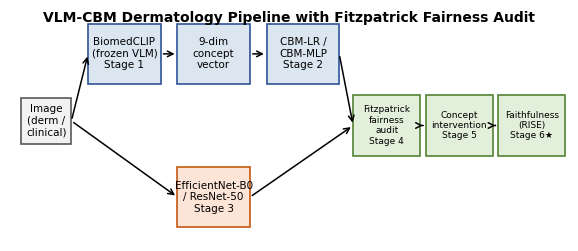

In [2]:
# Fig 1 : pipeline diagram
plots.plot_pipeline_diagram(figs_dir)

# Table 1 : dataset summary
tables.table1_dataset_summary(tables_dir)

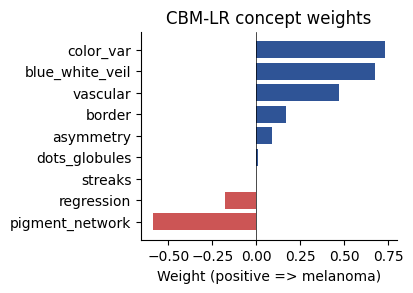

In [3]:
# Fig 8 - concept weights
ckpt = PROJECT_ROOT / paths['checkpoints_dir'] / 'cbm_lr.joblib'
if ckpt.exists():
    cbm = CBMLogisticRegression.load(ckpt)
    plots.plot_concept_weights(cbm.concept_weights(), out_dir=figs_dir)

In [ ]:
# Table 5 : concept AUROC on Derm7pt
p = cv_dir / 'concepts_derm7pt.npz'
if p.exists():
    b = load_concept_bundle(p)
    aur = per_concept_auroc(b['concepts'], b['concept_labels'], CONCEPT_IDS)
    tables.table5_concept_auroc(aur, tables_dir)
    print(aur)

{'pigment_network': 0.6343984857763179, 'dots_globules': 0.6988391271250951, 'blue_white_veil': 0.7752828054298643, 'streaks': 0.690716083036276, 'regression': nan, 'vascular': 0.6145156323441223, 'asymmetry': nan, 'border': nan, 'color_var': nan}


In [5]:
print('Figures written to', figs_dir)
for p in sorted(Path(figs_dir).glob('*.pdf')):
    print(' ', p.name)
print('\nTables written to', tables_dir)
for p in sorted(Path(tables_dir).glob('*')):
    print(' ', p.name)

Figures written to /Users/deepesh/Documents/Claude/Projects/AIH Final/vlm-cbm-derm-fairness/outputs/figures
  fig1_pipeline.pdf
  fig2_concept_auroc_heatmap.pdf
  fig3_per_bucket_auroc.pdf
  fig3_per_bucket_sensitivity.pdf
  fig5_intervention_rescue.pdf
  fig6_ablation_concept_count.pdf
  fig7_faithfulness.pdf
  fig8_concept_weights.pdf

Tables written to /Users/deepesh/Documents/Claude/Projects/AIH Final/vlm-cbm-derm-fairness/outputs/tables
  .gitkeep
  ablation_concept_count.csv
  ablation_concept_count.md
  ablation_concept_count.tex
  cbm_cv_summary.json
  intervention_per_concept.csv
  intervention_topk.csv
  table1_dataset_summary.csv
  table1_dataset_summary.md
  table1_dataset_summary.tex
  table3_per_bucket.csv
  table3_per_bucket.md
  table3_per_bucket.tex
  table4_fairness_gaps.csv
  table4_fairness_gaps.md
  table4_fairness_gaps.tex
  table5_concept_auroc.csv
  table5_concept_auroc.md
  table5_concept_auroc.tex
